# Customer Segmentation & Revenue Intelligence


## 1. Business Problem

Businesses have customers with different levels of transaction activity,
revenue contribution, and financial profiles.

The objective of this project is to use unsupervised machine learning to
identify meaningful customer segments and translate those segments into
actionable business strategies.

### Key Question

Can customer revenue behavior, transaction engagement, age, and income be
used to identify distinct customer groups?

### Business Objectives

- Identify customer groups with similar behavioral characteristics.
- Understand differences in customer value and engagement.
- Identify high-value and highly engaged customer groups.
- Develop targeted business strategies for each segment.

## 2. Import Libraries


In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# File handling
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Customer Data


In [2]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path(
    r"C:\Users\Dell\Downloads\DSAI-Portfolio\02-customer-segmentation\data\transactions_clean.sas7bdat"
)

df = pd.read_sas(
    DATA_PATH,
    format="sas7bdat"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (48016, 89)


In [3]:
df.head()

,State,IndivID,HHoldID,Title,Forename,Surname,CustomerSince,Birthdate,City,Country,Agent,Age,AgeGroup,Income,IncomeGroup,Gender,JobType,Language,MaritalStatus,Education,RevenueLst3Mnth,TransactionLst3Mnth,PromotedLst3Mnth,RevenueLst6Mnth,TransactionLst6Mnth,PromotedLst6Mnth,RevenueLst12Mnth,TransactionLst12Mnth,PromotedLst12Mnth,RevenueLast24Mnth,TransactionLst24Mnth,PromotedLst24Mnth,RevenueLst1Mnth,TransactionLst1Mnth,PromotedLst1Mnth,TikTokName,TikTokInfluence,FacebookName,FacebookInfluence,TikTokInfluenceScore,FacebookInfluenceScore,SMAInfluence,CreditScore,ChurnRisk,Savings1,Savings2,Savings3,Loans1,Loans2,Credit_Cards1,Insurance1,Insurance2,Insurance3,Checking_Accounts1,Credit_Cards2,Loans3,Loans4,Loans5,Loans6,Checking_Accounts2,Checking_Accounts3,Checking_Accounts4,Checking_Accounts5,Checking_Accounts6,Credit_Cards3,Credit_Cards4,Credit_Cards5,Credit_Cards6,Savings4,Savings5,Savings6,Insurance4,Insurance5,Savings7,Loans7,Credit_Cards7,Checking_Accounts7,Checking_Accounts8,Insurance6,Savings8,Savings9,Credit_Cards8,Savings10,Loans8,Insurance7,Loans9,Checking_Accounts9,Credit_Cards9,Credit_Cards10
0,b'Alabama',31768.00,12735.00,b'Mrs',b'Alyson',b'Sleeper',2005-09-29,1972-03-25,b'Mobile',b'United States',b'Agent_35',51.00,b'Middle Aged',3136.00,b'Unemployed',b'Male',b'Employee',b'French',b'Married',b'Secondary School',362.00,2489.00,1801.00,4249.00,2522.00,2676.00,6201.00,5021.00,3439.00,6629.00,5746.00,5279.00,212.00,145.00,143.00,b'AlysonSleeper',b'Follower',b'AlysonSleeper',b'Marginal',0.28,0.55,b'Marginal',0.65,0.02,2005-09-29,NaT,NaT,2005-09-29,1988-03-08,2005-09-29,2005-09-29,1995-03-25,1989-09-27,2011-07-04,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,b'Alabama',16442.00,6551.00,b'Mr',b'Kamala',b'Aschan',1992-03-24,1952-10-15,b'Mobile',b'United States',b'Agent_68',70.00,b'Retired',1135.00,b'Unemployed',b'Female',b'Owner',b'French',b'Widowed',b'Secondary School',551.00,2911.00,1455.00,2842.00,4261.00,5124.00,2887.00,5865.00,6169.00,3035.00,7097.00,7565.00,275.00,354.00,61.00,b'KamalaAschan',b'Outlier',b'KamalaAschan',b'Leader',0.65,0.77,b'Leader',0.91,0.14,1992-03-24,NaT,NaT,NaT,NaT,NaT,1992-03-24,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2,b'Alabama',68753.00,27474.00,b'Miss',b'Effie',b'Lacoss',2007-08-24,1957-04-06,b'Fayette',b'United States',b'Agent_24',66.00,b'Retired',9754.00,b'Unemployed',b'Male',b'Manager',b'German',b'Widowed',b'Secondary School',899.00,2821.00,2728.00,4091.00,4147.00,4540.00,5180.00,6853.00,6771.00,5544.00,8334.00,7987.00,89.00,255.00,439.00,b'EffieLacoss',b'Follower',b'EffieLacoss',b'Follower',0.14,0.08,b'Follower',0.50,0.46,2011-08-04,NaT,NaT,2017-11-23,1980-09-20,2020-01-11,2012-05-04,2017-02-24,NaT,NaT,2012-10-21,1982-08-26,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
3,b'Alabama',4528.00,1796.00,b'Ms',b'Stuart',b'Baginski',2013-06-11,1985-01-22,b'Dothan',b'United States',b'Agent_49',38.00,b'Adult',9788.00,b'Unemployed',b'Male',b'Employee',b'Spanish',b'Divorced',b'Secondary School',1835.00,3170.00,1596.00,3617.00,6932.00,3867.00,5074.00,9016.00,3891.00,6833.00,10119.00,4435.00,340.00,486.00,409.00,b'StuartBaginski',b'Leader',b'StuartBaginski',b'Marginal',0.84,0.52,b'Outlier',0.58,0.73,NaT,NaT,NaT,NaT,NaT,2013-06-11,NaT,NaT,NaT,2013-06-11,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
4,b'Alabama',30065.00,12038.00,b'Miss',b'Fabian',b'Drewett',2007-11-26,1975-08-06,b'Mobile',b'United States',b'Agent_78',47.00,b'Middle Aged',1884.00,b'Unemployed',b'Male',b'Manager',b'Spanish',b'Married',b'Secondary School',2177.00,2571.00,812.00,3817.00,3522.00,3511.00,4018.00,6005.00,6115.00,5142.00,6647.00,7763.00,109.00,185

## 4. Data Quality Assessment

In [4]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Dataset Shape: (48016, 89)

Data Types:
State                        object
IndivID                     float64
HHoldID                     float64
Title                        object
Forename                     object
                          ...      
Insurance7            datetime64[s]
Loans9                datetime64[s]
Checking_Accounts9    datetime64[s]
Credit_Cards9         datetime64[s]
Credit_Cards10        datetime64[s]
Length: 89, dtype: object

Missing Values:
Credit_Cards10        48016
Savings9              48016
Savings10             48016
Checking_Accounts9    48015
Loans9                48015
Credit_Cards9         48014
Insurance7            48013
Checking_Accounts8    48013
Loans8                48012
Savings8              48007
Credit_Cards8         48006
Checking_Accounts7    47992
Loans7                47991
Savings7              47987
Insurance6            47981
Credit_Cards7         47976
Savings6              47893
Checking_Accounts6    47885
Loans6           

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
IndivID,48015.00,51488.96,9.00,26066.50,51955.00,77920.50,100337.00,29438.99
HHoldID,48015.00,20569.48,4.00,10456.00,20771.00,31103.50,39999.00,11741.86
CustomerSince,48015,2004-12-10 21:54:00,1950-10-15 00:00:00,1995-10-30 00:00:00,2006-10-21 00:00:00,2015-02-07 00:00:00,2023-12-28 00:00:00,NaN
Birthdate,48013,1971-04-23 13:58:12,1923-09-12 00:00:00,1958-12-09 00:00:00,1970-06-09 00:00:00,1982-12-06 00:00:00,2013-08-17 00:00:00,NaN
Age,48013.00,51.75,9.00,40.00,53.00,64.00,99.00,17.25
...,...,...,...,...,...,...,...,...
Insurance7,3,1998-06-26 16:00:00,1987-08-11 00:00:00,1987-08-11 00:00:00,1987-08-11 00:00:00,2003-12-04 00:00:00,2020-03-28 00:00:00,NaN
Loans9,1,2020-09-29 00:00:00,2020-09-29 00:00:00,2020-09-29 00:00:00,2020-09-29 00:00:00,2020-09-29 00:00:00,2020-09-29 00:00:00,NaN
Checking_Accounts9,1,1985-09-25 00:00:00,1985-09-25 00:00:00,1985-09-25 00:00:00,1985-09-25 00:00:00,1985-09-25 00:00:00,1985-09-25 00:00:00,NaN
Credit_Cards9,2,2015-11-21 12:00:00,2014-12-12 00:00:00,2015-06-02 06:00:00,2015-11-21 12:00:00,2016-05-11 18:00:00,2016-10-31 00:00:00,NaN


## 5. Feature Engineering

The original customer dataset contains date, revenue, transaction, demographic,
and behavioral information.

New features are created to represent customer age, revenue behavior,
transaction engagement, and recent activity.

In [6]:
df["CustomerSince"] = pd.to_datetime(
    df["CustomerSince"],
    errors="coerce"
)

df["Birthdate"] = pd.to_datetime(
    df["Birthdate"],
    errors="coerce"
)

In [7]:
df["Age"] = (
    (pd.Timestamp.today() - df["Birthdate"]).dt.days / 365.25
)

### 5.1 Revenue Features
Revenue features capture recent customer value and changes in revenue behavior.

In [8]:
revenue_columns = [
    "RevenueLst1Mnth",
    "RevenueLst3Mnth",
    "RevenueLst6Mnth",
    "RevenueLst12Mnth",
    "RevenueLast24Mnth"
]

df[revenue_columns].describe()

,RevenueLst1Mnth,RevenueLst3Mnth,RevenueLst6Mnth,RevenueLst12Mnth,RevenueLast24Mnth
count,48015.00,48015.00,48015.00,48015.00,48015.00
mean,250.42,1995.33,4000.39,5496.61,6495.21
std,143.80,1018.67,1539.47,1771.60,1864.50
min,0.00,8.00,86.00,372.00,520.00
25%,126.00,1123.00,2889.00,4245.00,5188.50
50%,251.00,1989.00,3999.00,5491.00,6488.00
75%,375.00,2867.00,5106.00,6763.50,7806.00
max,500.00,3996.00,7974.00,10810.00,12322.00


In [9]:
df["Revenue_Recent"] = df["RevenueLst1Mnth"]

df["Revenue_3M_Avg"] = (
    df["RevenueLst3Mnth"] / 3
)

df["Revenue_6M_Avg"] = (
    df["RevenueLst6Mnth"] / 6
)

df["Revenue_12M_Avg"] = (
    df["RevenueLst12Mnth"] / 12
)

df["Revenue_24M_Avg"] = (
    df["RevenueLast24Mnth"] / 24
)

In [10]:
df["Revenue_Recent_Ratio"] = (
    df["Revenue_Recent"] /
    (df["Revenue_24M_Avg"])
)

### 5.2 Transaction & Engagement Features


In [11]:
transaction_columns = [
    "TransactionLst3Mnth",
    "TransactionLst6Mnth",
    "TransactionLst12Mnth",
    "TransactionLst24Mnth"
]

df[transaction_columns].describe()

,TransactionLst3Mnth,TransactionLst6Mnth,TransactionLst12Mnth,TransactionLst24Mnth
count,48015.00,48015.00,48015.00,48015.00
mean,1996.01,3995.16,5492.30,6495.43
std,1015.81,1536.08,1755.55,1847.64
min,3.00,138.00,224.00,501.00
25%,1129.00,2895.00,4250.50,5203.00
50%,1995.00,3993.00,5493.00,6492.00
75%,2867.00,5107.00,6730.00,7796.00
max,3995.00,7911.00,10796.00,12401.00


In [12]:
transaction_columns = [
    "TransactionLst3Mnth",
    "TransactionLst6Mnth",
    "TransactionLst12Mnth",
    "TransactionLst24Mnth"
]

df[transaction_columns].describe()

,TransactionLst3Mnth,TransactionLst6Mnth,TransactionLst12Mnth,TransactionLst24Mnth
count,48015.00,48015.00,48015.00,48015.00
mean,1996.01,3995.16,5492.30,6495.43
std,1015.81,1536.08,1755.55,1847.64
min,3.00,138.00,224.00,501.00
25%,1129.00,2895.00,4250.50,5203.00
50%,1995.00,3993.00,5493.00,6492.00
75%,2867.00,5107.00,6730.00,7796.00
max,3995.00,7911.00,10796.00,12401.00


In [13]:
df["Transactions_3M_Avg"] = (
    df["TransactionLst3Mnth"] / 3
)

df["Transactions_6M_Avg"] = (
    df["TransactionLst6Mnth"] / 6
)

df["Transactions_12M_Avg"] = (
    df["TransactionLst12Mnth"] / 12
)

df["Transactions_24M_Avg"] = (
    df["TransactionLst24Mnth"] / 24
)

df["Transaction_Recent_Ratio"] = (
    df["TransactionLst3Mnth"] /
    (df["TransactionLst24Mnth"] / 8)
)

In [14]:
df = df.copy()

df["Revenue_Per_Transaction_3M"] = (
    df["RevenueLst3Mnth"] /
    df["TransactionLst3Mnth"].replace(0, np.nan)
)

In [15]:
df["Revenue_Per_Transaction_3M"].describe()

count   48015.00
mean        1.70
std         5.89
min         0.00
25%         0.56
50%         1.00
75%         1.77
max      1088.67
Name: Revenue_Per_Transaction_3M, dtype: float64

## 6. Exploratory Data Analysis

Revenue distribution

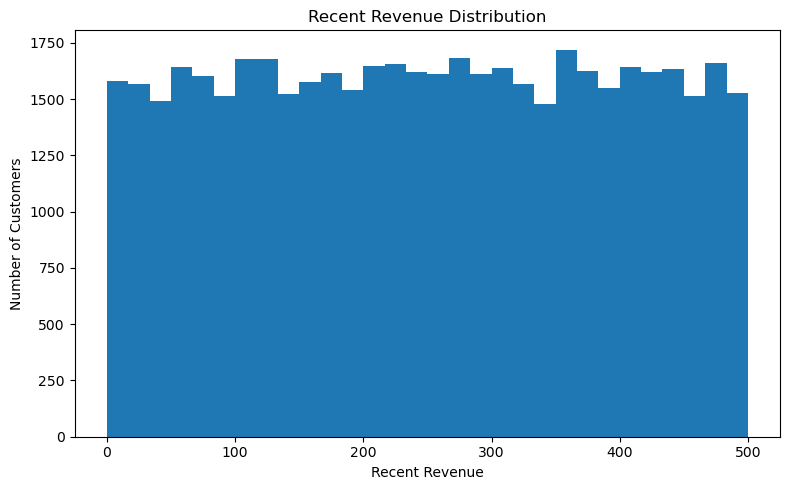

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Revenue_Recent"].dropna(),
    bins=30
)

plt.title("Recent Revenue Distribution")
plt.xlabel("Recent Revenue")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Transaction activity

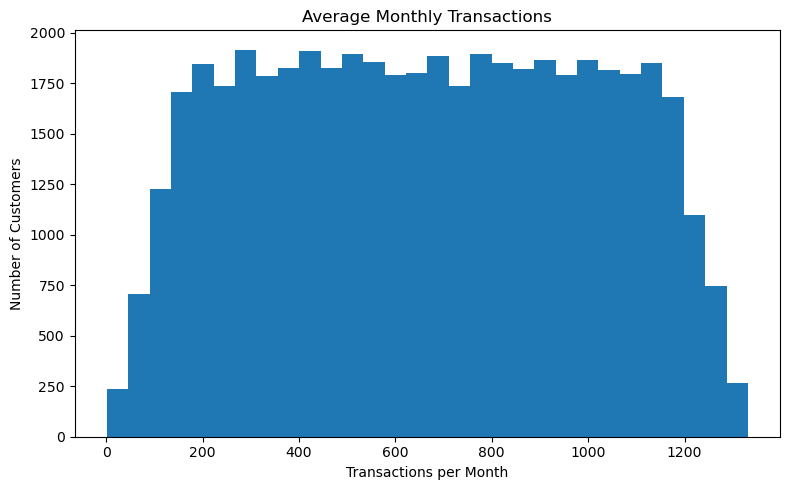

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Transactions_3M_Avg"].dropna(),
    bins=30
)

plt.title("Average Monthly Transactions")
plt.xlabel("Transactions per Month")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Age and income

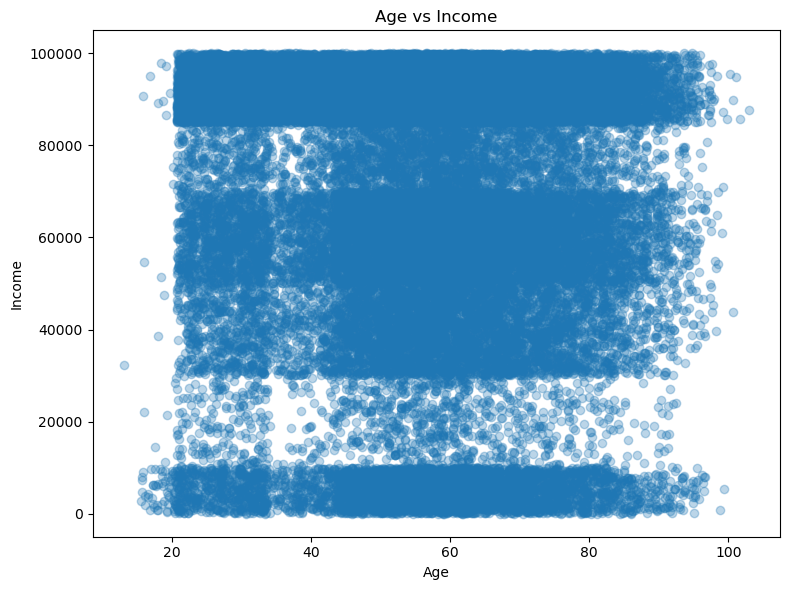

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Age"],
    df["Income"],
    alpha=0.3
)

plt.title("Age vs Income")
plt.xlabel("Age")
plt.ylabel("Income")

plt.tight_layout()
plt.show()

## 7. Segmentation Feature Selection

The final clustering model focuses on seven business-oriented variables
representing customer value, engagement, and customer profile.

In [19]:
segmentation_features = [
    "Revenue_Recent",
    "Revenue_Recent_Ratio",
    "Revenue_Per_Transaction_3M",
    "Transactions_3M_Avg",
    "Transaction_Recent_Ratio",
    "Age",
    "Income"
]

segmentation_df = df[segmentation_features].copy()

print("Segmentation dataset shape:", segmentation_df.shape)

Segmentation dataset shape: (48016, 7)


## 8. Missing Value Treatment

Median imputation is used for the segmentation variables. This approach
reduces the influence of extreme values compared with mean imputation.

In [20]:
print("Missing values before treatment:")
print(segmentation_df.isnull().sum())

Missing values before treatment:
Revenue_Recent                  1
Revenue_Recent_Ratio            1
Revenue_Per_Transaction_3M      1
Transactions_3M_Avg             1
Transaction_Recent_Ratio        1
Age                             3
Income                        635
dtype: int64


In [21]:
segmentation_clean = segmentation_df.copy()

segmentation_clean = segmentation_clean.fillna(
    segmentation_clean.median()
)

print("\nMissing values after treatment:")
print(segmentation_clean.isnull().sum())


Missing values after treatment:
Revenue_Recent                0
Revenue_Recent_Ratio          0
Revenue_Per_Transaction_3M    0
Transactions_3M_Avg           0
Transaction_Recent_Ratio      0
Age                           0
Income                        0
dtype: int64


## 9. Feature Transformation

Several financial and behavioral variables are right-skewed. Logarithmic
transformation is used to reduce the influence of extreme values while
preserving customer observations.

In [22]:
log_features = [
    "Revenue_Recent",
    "Revenue_Recent_Ratio",
    "Revenue_Per_Transaction_3M",
    "Transactions_3M_Avg",
    "Transaction_Recent_Ratio",
    "Income"
]

segmentation_log = segmentation_clean.copy()

for feature in log_features:
    segmentation_log[feature] = np.log1p(
        segmentation_log[feature]
    )

segmentation_log.describe().T

,count,mean,std,min,25%,50%,75%,max
Revenue_Recent,48016.00,5.23,0.96,0.00,4.84,5.53,5.93,6.22
Revenue_Recent_Ratio,48016.00,0.64,0.34,0.00,0.39,0.65,0.87,2.48
Revenue_Per_Transaction_3M,48016.00,0.80,0.52,0.00,0.44,0.69,1.02,6.99
Transactions_3M_Avg,48016.00,6.31,0.70,0.69,5.93,6.50,6.86,7.19
Transaction_Recent_Ratio,48016.00,1.18,0.36,0.01,0.96,1.24,1.44,2.14
Age,48016.00,55.33,17.35,13.02,43.71,56.21,67.70,102.95
Income,48016.00,10.90,0.98,0.00,10.86,11.34,11.43,11.51


## 10. Feature Scaling

StandardScaler is applied so that variables with different numerical ranges
have comparable influence during K-Means clustering.

In [23]:
final_segmentation_features = [
    "Revenue_Recent",
    "Revenue_Recent_Ratio",
    "Revenue_Per_Transaction_3M",
    "Transactions_3M_Avg",
    "Transaction_Recent_Ratio",
    "Age",
    "Income"
]

X_seg = segmentation_log[
    final_segmentation_features
].copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_seg)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (48016, 7)


In [24]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=final_segmentation_features
)

X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Revenue_Recent,48016.00,0.00,1.00,-5.48,-0.41,0.31,0.73,1.03
Revenue_Recent_Ratio,48016.00,0.00,1.00,-1.91,-0.75,0.04,0.69,5.50
Revenue_Per_Transaction_3M,48016.00,-0.00,1.00,-1.53,-0.68,-0.21,0.42,11.92
Transactions_3M_Avg,48016.00,-0.00,1.00,-8.05,-0.55,0.27,0.79,1.26
Transaction_Recent_Ratio,48016.00,0.00,1.00,-3.28,-0.63,0.16,0.72,2.67
Age,48016.00,-0.00,1.00,-2.44,-0.67,0.05,0.71,2.74
Income,48016.00,0.00,1.00,-11.09,-0.04,0.45,0.54,0.63


## 11. Selecting the Optimal Number of Clustmers

K-Means models with K values from 2 through 8 are evaluated using the
Silhouette Score.

The configuration with the highest score is selected as the final clustering
solution.

In [25]:
silhouette_scores = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "K": range(2, 9),
    "Silhouette_Score": silhouette_scores
})

silhouette_results

,K,Silhouette_Score
0,2,0.28
1,3,0.24
2,4,0.26
3,5,0.21
4,6,0.20
5,7,0.18
6,8,0.19


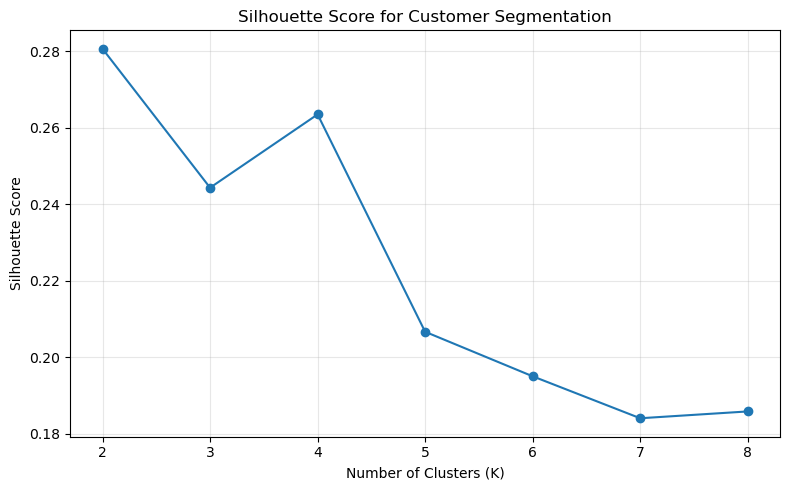

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_results["K"],
    silhouette_results["Silhouette_Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Customer Segmentation")

plt.xticks(range(2, 9))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
optimal_k = int(
    silhouette_results.loc[
        silhouette_results["Silhouette_Score"].idxmax(),
        "K"
    ]
)

best_score = silhouette_results[
    "Silhouette_Score"
].max()

print("Optimal K:", optimal_k)
print("Best Silhouette Score:", round(best_score, 4))

Optimal K: 2
Best Silhouette Score: 0.2806


## 12. Final K-Means Segmentation


In [28]:
final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

segment_labels = final_kmeans.fit_predict(X_scaled)

segmentation_clean["Segment"] = segment_labels

In [29]:
segmentation_clean["Segment"].value_counts().sort_index()

Segment
0    34808
1    13208
Name: count, dtype: int64

## 13. Segment Profiling


In [30]:
segment_summary = (
    segmentation_clean
    .groupby("Segment")
    .agg(
        Customer_Count=("Segment", "size"),
        Avg_Recent_Revenue=("Revenue_Recent", "mean"),
        Avg_Recent_Revenue_Ratio=("Revenue_Recent_Ratio", "mean"),
        Avg_Revenue_Per_Transaction=(
            "Revenue_Per_Transaction_3M", "mean"
        ),
        Avg_Monthly_Transactions=(
            "Transactions_3M_Avg", "mean"
        ),
        Avg_Transaction_Recent_Ratio=(
            "Transaction_Recent_Ratio", "mean"
        ),
        Avg_Age=("Age", "mean"),
        Avg_Income=("Income", "mean")
    )
    .reset_index()
)

segment_summary["Customer_Share_%"] = (
    segment_summary["Customer_Count"]
    / len(segmentation_clean)
    * 100
).round(2)

segment_summary.round(2)

,Segment,Customer_Count,Avg_Recent_Revenue,Avg_Recent_Revenue_Ratio,Avg_Revenue_Per_Transaction,Avg_Monthly_Transactions,Avg_Transaction_Recent_Ratio,Avg_Age,Avg_Income,Customer_Share_%
0,0,34808,249.01,1.02,0.84,821.97,2.96,55.34,68920.38,72.49
1,1,13208,254.12,0.99,3.97,252.55,1.15,55.31,68512.40,27.51


## 14. Segment Names

In [31]:
segment_names = {
    0: "High-Engagement Core Customers",
    1: "High-Value Occasional Customers",
    2: "Lower-Income Customers"
}

segmentation_clean["Segment_Name"] = (
    segmentation_clean["Segment"]
    .map(segment_names)
)

segment_summary["Segment_Name"] = (
    segment_summary["Segment"]
    .map(segment_names)
)

segment_summary.round(2)

,Segment,Customer_Count,Avg_Recent_Revenue,Avg_Recent_Revenue_Ratio,Avg_Revenue_Per_Transaction,Avg_Monthly_Transactions,Avg_Transaction_Recent_Ratio,Avg_Age,Avg_Income,Customer_Share_%,Segment_Name
0,0,34808,249.01,1.02,0.84,821.97,2.96,55.34,68920.38,72.49,High-Engagement Core Customers
1,1,13208,254.12,0.99,3.97,252.55,1.15,55.31,68512.40,27.51,High-Value Occasional Customers


## 15. Business Recommendations

### High-Engagement Core Customers

This is the largest customer group and demonstrates strong transaction
engagement.

**Recommended actions:**
- Retention and loyalty programs
- Cross-selling
- Personalized engagement
- Increasing average transaction value

### High-Value Occasional Customers

This group has lower transaction frequency but substantially higher revenue
per transaction.

**Recommended actions:**
- Personalized offers
- Premium products and services
- Reactivation campaigns
- Increasing purchase frequency

### Lower-Income Customers

This group is primarily distinguished by its lower reported income profile
while maintaining meaningful transaction activity.

**Recommended actions:**
- Value-oriented products
- Affordable packages
- Targeted promotions
- Price-sensitive campaigns

In [32]:
FIGURE_DIR = Path(
    "../outputs/figures"
)

print("Output directory:", FIGURE_DIR.resolve())
print("Files:")

for file in FIGURE_DIR.iterdir():
    print("-", file.name)

Output directory: C:\Users\Dell\Downloads\DSAI-Portfolio\02-customer-segmentation\outputs\figures
Files:
- customer-segment-distribution.png
- segment-revenue-comparison.png


## 16. Final Conclusions

The customer segmentation analysis identified three distinct customer groups
using revenue behavior, transaction activity, recent engagement, age, and income.

Silhouette analysis evaluated cluster counts from K=2 through K=8 and identified
K=3 as the best-performing configuration, with a silhouette score of approximately
0.281.

The resulting segments were:

1. High-Engagement Core Customers
   - Largest customer group
   - High transaction activity
   - Opportunity for retention, loyalty, and cross-selling

2. High-Value Occasional Customers
   - Lower transaction frequency
   - Highest revenue per transaction
   - Opportunity to increase purchase frequency through personalized and premium offers

3. Lower-Income Customers
   - Distinctly lower reported income profile
   - Maintains meaningful transaction activity
   - Opportunity for value-oriented products and targeted promotions

The analysis demonstrates how unsupervised machine learning can transform
customer-level behavioral data into actionable business segments.

In [33]:
print("=" * 60)
print("FINAL PROJECT QA")
print("=" * 60)

print("\nDataset shape:", df.shape)
print("Segmentation data shape:", segmentation_clean.shape)

print("\nOptimal K:", optimal_k)
print("Best Silhouette Score:", round(best_score, 4))

print("\nSegment Distribution:")
print(
    segmentation_clean["Segment_Name"]
    .value_counts()
)

print("\nOutput Figures:")
for file in FIGURE_DIR.iterdir():
    print("-", file.name)

print("\nMissing Values:")
print(
    segmentation_clean[
        final_segmentation_features
    ].isnull().sum().sum()
)

print("\nFINAL QA COMPLETE")

FINAL PROJECT QA

Dataset shape: (48016, 101)
Segmentation data shape: (48016, 9)

Optimal K: 2
Best Silhouette Score: 0.2806

Segment Distribution:
Segment_Name
High-Engagement Core Customers     34808
High-Value Occasional Customers    13208
Name: count, dtype: int64

Output Figures:
- customer-segment-distribution.png
- segment-revenue-comparison.png

Missing Values:
0

FINAL QA COMPLETE
